## Customer Churn Prediction

In [45]:
# Importing libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## Loading data and EDA

In [36]:
#Import the datasets from github
url = 'https://raw.githubusercontent.com/Levice085/Customer_churn_prediction/refs/heads/main/datasets/Telco-Customer-Churn.csv'
response = requests.get(url)

with open("churn.csv", "wb") as f:
    f.write(response.content)
df = pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
print(f"The shape of the dataset is: {(df.shape)}")
print(f"Total columns: {len(df.columns)}")
print(f"The column names are: {df.columns.tolist()}")

The shape of the dataset is: (7043, 21)
Total columns: 21
The column names are: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [38]:
#Viewing the columns data types
print(f"The column data types are: {df.dtypes}")

The column data types are: customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Churn
No     5174
Yes    1869
Name: count, dtype: int64
 The churn rate is: 26.54%


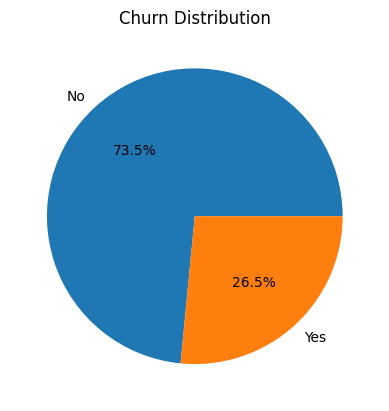

In [39]:
#Finding the churn rate
print(df["Churn"].value_counts())
print(f" The churn rate is: {df["Churn"].eq("Yes").mean()*100:.2f}%")

#Visualizing the churn rate
df["Churn"].value_counts().plot(
    kind = 'pie',
    title = "Churn Distribution",
    autopct = '%1.1f%%'
)

plt.ylabel('')
plt.show()

In [40]:
#Checking for missing data
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [41]:
#Summary of binary columns
df[["SeniorCitizen","tenure","MonthlyCharges"]].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


<Axes: >

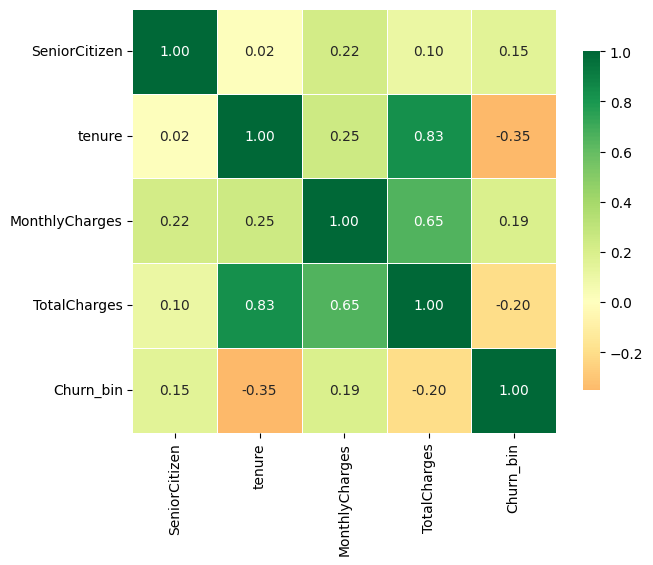

In [64]:
#Generate a correlation map
df_temp = df.copy()
df_temp["TotalCharges"] = pd.to_numeric(df_temp["TotalCharges"], errors = 'coerce')

df_temp["Churn_bin"] = (df_temp["Churn"] == "Yes").astype(int)
num_cols = ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","Churn_bin"]

#Correlation
corr = df_temp[num_cols].corr()

fig, ax = plt.subplots(figsize = (7, 5.5))
sns.heatmap(corr, annot = True, cmap = 'RdYlGn', fmt = '.2f',ax=ax, center = 0, 
                linewidths = 0.5,square = True,cbar_kws = {'shrink':0.8})

